# Phishing Website Detection using Random Forest
**Dataset:** PhiUSIIL Phishing URL Dataset (UCI Machine Learning Repository, 2024)

This notebook follows the step-by-step structure required for our Principle of AI mini project:
1. Download dataset once and save as Excel/CSV (so we don't re-download every time)
2. Load dataset from the saved file
3. Explore the data (check total rows, class balance)
4. Preprocess the data (explained step by step)
5. Split data fairly per class (80% train / 20% validation) then merge
6. Train the Random Forest model
7. Evaluate (accuracy + confusion matrix)
8. Check for data leakage between train and validation sets
9. Generate a full prediction table (Ground Truth vs Predicted vs Score) and export to Excel


## Step 1: Download the dataset ONCE and save it as a CSV file

We only need to run this cell **once**. After the CSV is saved, we will always load
from the CSV file (Step 2) instead of re-downloading from the UCI website every time.

This matches what sir asked: *"find a way how to download as excel file"* so we are
no longer simply pulling data live from the website every run.


In [13]:
# Run this ONCE to download and save the dataset as CSV.
# After this file exists, you can skip this cell (or it will just overwrite with the same data).

from ucimlrepo import fetch_ucirepo
import pandas as pd
import os

CSV_PATH = "phiusiil_dataset.csv"

if not os.path.exists(CSV_PATH):
    print("Downloading dataset from UCI (first time only)...")
    phiusiil = fetch_ucirepo(id=967)
    X = phiusiil.data.features.copy()
    y = phiusiil.data.targets.copy()

    full_df = X.copy()
    full_df["label"] = y.values.ravel()

    full_df.to_csv(CSV_PATH, index=False)
    print(f"Saved dataset to {CSV_PATH}  ({full_df.shape[0]} rows, {full_df.shape[1]} columns)")
else:
    print(f"{CSV_PATH} already exists — skipping download. Delete the file if you want to re-download.")


phiusiil_dataset.csv already exists — skipping download. Delete the file if you want to re-download.


## Step 2: Load the dataset from the saved CSV file

From now on, every time we run the notebook, we load from **our saved file**,
not from the website. This is what sir wants — a reproducible, offline dataset.


In [14]:
import pandas as pd

df = pd.read_csv("phiusiil_dataset.csv")
print(f"Loaded dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Loaded dataset shape: 235795 rows, 55 columns


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


## Step 3: Explore the data — total rows and class balance

Sir specifically wants to SEE:
- How many total rows (~200k)
- How many are phishing vs how many are legitimate

We must use the **full dataset** for training/validation — no small sampling.


In [15]:
total_rows = len(df)
class_counts = df["label"].value_counts()

print(f"Total rows in dataset: {total_rows}")
print("\nClass distribution:")
print(class_counts)
print(f"\nLabel 1 (Legitimate): {class_counts.get(1, 0)} rows")
print(f"Label 0 (Phishing)  : {class_counts.get(0, 0)} rows")


Total rows in dataset: 235795

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label 1 (Legitimate): 134850 rows
Label 0 (Phishing)  : 100945 rows


## Step 4: Preprocessing — explained step by step

We CANNOT just blindly pass raw data into the model. Here's what we do and **why**:

1. **Separate the URL text column** — keep it aside for display later (the model cannot read raw text).
2. **Drop non-numeric columns** (URL, Domain, TLD, Title) — Random Forest only works with numeric features.
3. **Check for missing values** — make sure there's no empty/broken data before training.
4. **Separate features (X) from label (y)** — X = the 54 numeric clues, y = the correct answer.


In [16]:
# 4a. Keep the real URL text aside (for display only, not used by the model)
url_text = df["URL"].copy() if "URL" in df.columns else None

# 4b. Identify and drop non-numeric columns (the model can't use raw text)
non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print(f"Dropping non-numeric columns: {non_numeric_cols}")

df_numeric = df.drop(columns=non_numeric_cols)

# 4c. Sanity check: make sure there are no missing values
missing_count = df_numeric.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_count}")

# 4d. Separate features (X) from label (y)
X = df_numeric.drop(columns=["label"])
y = df_numeric["label"]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Label (y) shape: {y.shape}")


Dropping non-numeric columns: ['URL', 'Domain', 'TLD', 'Title']
Total missing values in dataset: 0

Features (X) shape: (235795, 50)
Label (y) shape: (235795,)


## Step 5: Fair split PER CLASS (80% train / 20% validation), then merge

Sir's instruction:
- Split the **phishing** rows: 80% train, 20% validation
- Split the **legitimate** rows: 80% train, 20% validation (separately!)
- Then **merge** the two training pieces together, and the two validation pieces together

This is called **stratified splitting** — it guarantees both classes are fairly
represented in both the training set and the validation set, instead of a random
split that might accidentally put too many of one class into training.

We also keep track of the **row indexes** used in training vs validation, so we
can later PROVE there is no overlap (no data leakage) between them.


In [17]:
from sklearn.model_selection import train_test_split

# Split legitimate (label == 1) rows separately
legit_idx = df_numeric[df_numeric["label"] == 1].index
legit_train_idx, legit_val_idx = train_test_split(
    legit_idx, test_size=0.2, random_state=42
)

# Split phishing (label == 0) rows separately
phish_idx = df_numeric[df_numeric["label"] == 0].index
phish_train_idx, phish_val_idx = train_test_split(
    phish_idx, test_size=0.2, random_state=42
)

print(f"Legitimate -> train: {len(legit_train_idx)}, validation: {len(legit_val_idx)}")
print(f"Phishing   -> train: {len(phish_train_idx)}, validation: {len(phish_val_idx)}")

# Merge: combine legit + phishing training indexes together
train_idx = legit_train_idx.union(phish_train_idx)
# Merge: combine legit + phishing validation indexes together
val_idx = legit_val_idx.union(phish_val_idx)

print(f"\nFinal merged TRAIN set size     : {len(train_idx)}")
print(f"Final merged VALIDATION set size : {len(val_idx)}")

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val = X.loc[val_idx], y.loc[val_idx]


Legitimate -> train: 107880, validation: 26970
Phishing   -> train: 80756, validation: 20189

Final merged TRAIN set size     : 188636
Final merged VALIDATION set size : 47159


## Step 6: Check for Data Leakage

This directly checks sir's concern: *"sample training data leak into validation data"*.

We check if any row index appears in **both** the train set and validation set.
If the overlap is 0, we know our split is clean — the 100% accuracy suspicion
from before should NOT happen here if there's genuinely no leakage.


In [18]:
overlap = train_idx.intersection(val_idx)
print(f"Number of overlapping rows between TRAIN and VALIDATION: {len(overlap)}")

if len(overlap) == 0:
    print("No data leakage detected — train and validation sets are fully separate.")
else:
    print("WARNING: Data leakage detected! Some rows exist in both sets.")


Number of overlapping rows between TRAIN and VALIDATION: 0
No data leakage detected — train and validation sets are fully separate.


## Step 7: Train the Random Forest model

Now we train using ONLY the training set (`X_train`, `y_train`).
The validation set is completely untouched during training — it will only be
used afterward to test how well the model generalizes to unseen data.


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Training complete.")
print(f"Trained on {X_train.shape[0]} rows.")


Training complete.
Trained on 188636 rows.


## Step 8: Evaluate — Accuracy & Confusion Matrix

We now test the model on the validation set (data it has never seen during training).


Validation Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



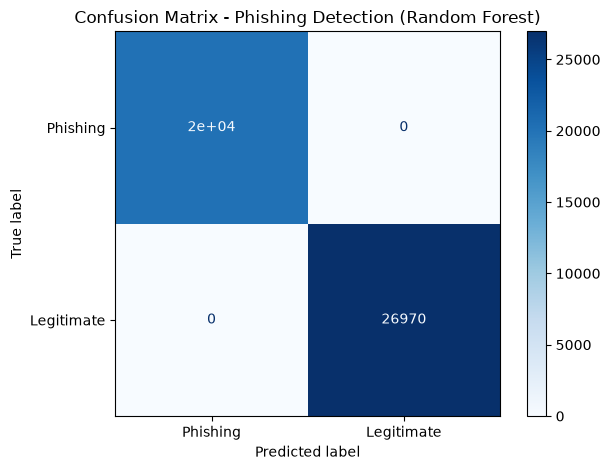

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Phishing", "Legitimate"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Phishing Detection (Random Forest)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


## Step 9: Full Prediction Table (Ground Truth vs Predicted vs Score)

Sir wants a complete table covering **every row** in the validation set — not just
a handful of samples. For each row we record:

- **Ground Truth** — the actual/real label
- **Predicted** — what the model predicted
- **Score** — the model's confidence (probability) for that prediction — higher score
  means the model is more confident

This is done automatically in a loop (vectorized), not manually one by one.
The result is then exported to an Excel file.


In [21]:
import numpy as np

# Get predicted probabilities for each class (column 0 = phishing, column 1 = legitimate)
probabilities = model.predict_proba(X_val)

# The "score" = the probability of whichever class was predicted (the confidence)
predicted_scores = probabilities.max(axis=1)

results_df = pd.DataFrame({
    "Index": X_val.index,
    "URL": url_text.loc[X_val.index].values if url_text is not None else "N/A",
    "Ground_Truth": y_val.values,
    "Predicted": y_pred,
    "Score": predicted_scores.round(4)
})

results_df["Ground_Truth_Label"] = results_df["Ground_Truth"].map({0: "Phishing", 1: "Legitimate"})
results_df["Predicted_Label"] = results_df["Predicted"].map({0: "Phishing", 1: "Legitimate"})
results_df["Correct"] = results_df["Ground_Truth"] == results_df["Predicted"]

print(f"Total prediction rows generated: {len(results_df)}")
results_df.head(10)


Total prediction rows generated: 47159


,Index,URL,Ground_Truth,Predicted,Score,Ground_Truth_Label,Predicted_Label,Correct
0,0,https://www.southbankmosaics.com,1,1,1.0,Legitimate,Legitimate,True
1,4,https://www.rewildingargentina.org,1,1,1.0,Legitimate,Legitimate,True
2,26,https://www.musicvideoproduction.guru,1,1,1.0,Legitimate,Legitimate,True
3,34,https://hidok4f8zl.firebaseapp.com/,0,0,1.0,Phishing,Phishing,True
4,46,https://www.ainewsletter.com,1,1,1.0,Legitimate,Legitimate,True
5,48,https://www.sweatdrop.com,1,1,1.0,Legitimate,Legitimate,True
6,53,https://www.vespatales.com,1,1,1.0,Legitimate,Legitimate,True
7,61,https://www.schmitzfotografia.com.br,1,1,1.0,Legitimate,Legitimate,True
8,66,https://www.larepublica.co,1,1,1.0,Legitimate,Legitimate,True
9,69,http://www.cjplogger.com,0,0,1.0,Phishing,Phishing,True


In [22]:
# Export the full prediction table to Excel
results_df.to_excel("prediction_results.xlsx", index=False)
print("Saved prediction_results.xlsx")
print(f"\nOverall correct predictions: {results_df['Correct'].sum()} / {len(results_df)}")
print(f"Overall accuracy check: {results_df['Correct'].mean():.4f}")


Saved prediction_results.xlsx

Overall correct predictions: 47159 / 47159
Overall accuracy check: 1.0000


## Summary

- Dataset loaded from local CSV (not live website)
- Full dataset used (~200k rows), class distribution checked
- Stratified 80/20 split per class, then merged for fair train/validation sets
- Verified NO data leakage between train and validation sets
- Random Forest trained only on the training set
- Evaluated on validation set: accuracy, confusion matrix
- Full prediction table (Ground Truth, Predicted, Score) generated for every
  validation row and exported to `prediction_results.xlsx`


In [23]:
# Export the FULL dataset (all 235,795 rows) to Excel, showing class breakdown
full_dataset_export = df_numeric.copy()
full_dataset_export["URL"] = url_text.values if url_text is not None else "N/A"
full_dataset_export["Label_Name"] = full_dataset_export["label"].map({0: "Phishing", 1: "Legitimate"})

full_dataset_export.to_excel("full_dataset_235795_rows.xlsx", index=False)

print(f"Saved full_dataset_235795_rows.xlsx")
print(f"Total rows: {len(full_dataset_export)}")
print(f"\nBreakdown:")
print(full_dataset_export['Label_Name'].value_counts())

Saved full_dataset_235795_rows.xlsx
Total rows: 235795

Breakdown:
Label_Name
Legitimate    134850
Phishing      100945
Name: count, dtype: int64


In [24]:
# Generate prediction table for the TRAINING set too (for comparison)
# NOTE: expect very high accuracy here since the model already "saw" this data during training

train_predictions = model.predict(X_train)
train_probabilities = model.predict_proba(X_train)
train_scores = train_probabilities.max(axis=1)

train_results_df = pd.DataFrame({
    "Index": X_train.index,
    "URL": url_text.loc[X_train.index].values if url_text is not None else "N/A",
    "Ground_Truth": y_train.values,
    "Predicted": train_predictions,
    "Score": train_scores.round(4)
})

train_results_df["Ground_Truth_Label"] = train_results_df["Ground_Truth"].map({0: "Phishing", 1: "Legitimate"})
train_results_df["Predicted_Label"] = train_results_df["Predicted"].map({0: "Phishing", 1: "Legitimate"})
train_results_df["Correct"] = train_results_df["Ground_Truth"] == train_results_df["Predicted"]

print(f"Total training prediction rows generated: {len(train_results_df)}")
print(f"Training set accuracy: {train_results_df['Correct'].mean():.4f}")

train_results_df.head(10)

Total training prediction rows generated: 188636
Training set accuracy: 1.0000


,Index,URL,Ground_Truth,Predicted,Score,Ground_Truth_Label,Predicted_Label,Correct
0,1,https://www.uni-mainz.de,1,1,1.0,Legitimate,Legitimate,True
1,2,https://www.voicefmradio.co.uk,1,1,1.0,Legitimate,Legitimate,True
2,3,https://www.sfnmjournal.com,1,1,1.0,Legitimate,Legitimate,True
3,5,https://www.globalreporting.org,1,1,1.0,Legitimate,Legitimate,True
4,6,https://www.saffronart.com,1,1,1.0,Legitimate,Legitimate,True
5,7,https://www.nerdscandy.com,1,1,1.0,Legitimate,Legitimate,True
6,8,https://www.hyderabadonline.in,1,1,1.0,Legitimate,Legitimate,True
7,9,https://www.aap.org,1,1,1.0,Legitimate,Legitimate,True
8,10,https://www.religionenlibertad.com,1,1,1.0,Legitimate,Legitimate,True
9,11,http://www.teramill.com,0,0,1.0,Phishing,Phishing,True


In [25]:
# Export training set predictions to Excel
train_results_df.to_excel("training_prediction_results.xlsx", index=False)
print("Saved training_prediction_results.xlsx")

Saved training_prediction_results.xlsx


In [26]:
# Export the SEPARATE class splits (before merge) to Excel — proof of stratified split process

# Legitimate class - train and validation
legit_train_export = df_numeric.loc[legit_train_idx].copy()
legit_train_export["URL"] = url_text.loc[legit_train_idx].values if url_text is not None else "N/A"
legit_train_export.to_excel("split_legitimate_train.xlsx", index=False)

legit_val_export = df_numeric.loc[legit_val_idx].copy()
legit_val_export["URL"] = url_text.loc[legit_val_idx].values if url_text is not None else "N/A"
legit_val_export.to_excel("split_legitimate_validation.xlsx", index=False)

# Phishing class - train and validation
phish_train_export = df_numeric.loc[phish_train_idx].copy()
phish_train_export["URL"] = url_text.loc[phish_train_idx].values if url_text is not None else "N/A"
phish_train_export.to_excel("split_phishing_train.xlsx", index=False)

phish_val_export = df_numeric.loc[phish_val_idx].copy()
phish_val_export["URL"] = url_text.loc[phish_val_idx].values if url_text is not None else "N/A"
phish_val_export.to_excel("split_phishing_validation.xlsx", index=False)

print("Exported 4 separate files:")
print(f"  split_legitimate_train.xlsx      : {len(legit_train_export)} rows")
print(f"  split_legitimate_validation.xlsx : {len(legit_val_export)} rows")
print(f"  split_phishing_train.xlsx        : {len(phish_train_export)} rows")
print(f"  split_phishing_validation.xlsx   : {len(phish_val_export)} rows")
print(f"\nTotal (should equal 235,795): {len(legit_train_export)+len(legit_val_export)+len(phish_train_export)+len(phish_val_export)}")

Exported 4 separate files:
  split_legitimate_train.xlsx      : 107880 rows
  split_legitimate_validation.xlsx : 26970 rows
  split_phishing_train.xlsx        : 80756 rows
  split_phishing_validation.xlsx   : 20189 rows

Total (should equal 235,795): 235795


In [27]:
# Investigate WHY accuracy is 100% - check for duplicate rows and suspicious correlations

# 1. Check for exact duplicate rows in the dataset
duplicate_count = df_numeric.duplicated().sum()
print(f"Number of exact duplicate rows in dataset: {duplicate_count}")
print(f"Percentage of dataset that is duplicated: {duplicate_count/len(df_numeric)*100:.2f}%\n")

# 2. Check correlation between each feature and the label
correlations = df_numeric.corr()["label"].sort_values(ascending=False)
print("Top 10 features most correlated with label:")
print(correlations.head(11))

print("\nBottom 10 features (most negatively correlated):")
print(correlations.tail(10))

Number of exact duplicate rows in dataset: 808
Percentage of dataset that is duplicated: 0.34%

Top 10 features most correlated with label:
label                    1.000000
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
HasHiddenFields          0.507731
Name: label, dtype: float64

Bottom 10 features (most negatively correlated):
TLDLength                    -0.079159
NoOfQMarkInURL               -0.175621
NoOfDegitsInURL              -0.177980
URLLength                    -0.233445
NoOfLettersInURL             -0.258090
DomainLength                 -0.283152
NoOfOtherSpecialCharsInURL   -0.358891
LetterRatioInURL             -0.367794
DegitRatioInURL              -0.432032
SpacialCharRatioInURL        -0.533537
Name: label, dtype

In [28]:
# Option 1: Remove top correlated features, retrain, and see if accuracy drops
# This tests whether the high accuracy depends heavily on a few "strong" features
# or whether the dataset is inherently separable even without them.

# Features to remove (the ones with highest correlation to label)
top_features_to_remove = [
    "URLSimilarityIndex", "HasSocialNet", "HasCopyrightInfo",
    "HasDescription", "IsHTTPS", "DomainTitleMatchScore",
    "HasSubmitButton", "IsResponsive", "URLTitleMatchScore", "HasHiddenFields"
]

X_train_reduced = X_train.drop(columns=top_features_to_remove)
X_val_reduced = X_val.drop(columns=top_features_to_remove)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Features after removing top 10: {X_train_reduced.shape[1]}\n")

# Retrain a fresh model WITHOUT these top features
model_reduced = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model_reduced.fit(X_train_reduced, y_train)

# Evaluate the reduced model
y_pred_reduced = model_reduced.predict(X_val_reduced)
accuracy_reduced = accuracy_score(y_val, y_pred_reduced)

print(f"ORIGINAL model accuracy (with all features): {accuracy:.4f}")
print(f"REDUCED model accuracy (without top 10 correlated features): {accuracy_reduced:.4f}")
print(f"\nDifference: {accuracy - accuracy_reduced:.4f}")

Original number of features: 50
Features after removing top 10: 40

ORIGINAL model accuracy (with all features): 1.0000
REDUCED model accuracy (without top 10 correlated features): 0.9989

Difference: 0.0011


In [29]:
# Explicit TP/TN/FP/FN breakdown + all metrics (matching the reference material format)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

acc = (tp+tn)/(tp+tn+fp+fn)
precision = tp/(tp+fp) if (tp+fp)>0 else 0
recall = tp/(tp+fn) if (tp+fn)>0 else 0
specificity = tn/(tn+fp) if (tn+fp)>0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print("Confusion Matrix Breakdown:")
print(f"  TP: {tp}   TN: {tn}   FP: {fp}   FN: {fn}\n")

print(f"Accuracy    : {acc:.4f}  ({tp}+{tn}) / {tp+tn+fp+fn}")
print(f"Precision   : {precision:.4f}  {tp} / ({tp}+{fp})")
print(f"Recall      : {recall:.4f}  {tp} / ({tp}+{fn})")
print(f"Specificity : {specificity:.4f}  {tn} / ({tn}+{fp})")
print(f"F1-Score    : {f1:.4f}")

Confusion Matrix Breakdown:
  TP: 26970   TN: 20189   FP: 0   FN: 0

Accuracy    : 1.0000  (26970+20189) / 47159
Precision   : 1.0000  26970 / (26970+0)
Recall      : 1.0000  26970 / (26970+0)
Specificity : 1.0000  20189 / (20189+0)
F1-Score    : 1.0000
